# Deepfake detection: denoising + imbalance handling + F1-oriented training

Ноутбук для **VS Code / Jupyter локально**.

Что включено:
- чтение датасета из `dataset/...`;
- **медианная предобработка шума**;
- борьба с дисбалансом через `pos_weight` и `WeightedRandomSampler`;
- собственная CNN-архитектура;
- валидация с подбором **threshold по F1**;
- логирование `precision`, `recall`, `f1`, `accuracy`;
- early stopping по `val_f1`;
- сохранение лучшей модели и `submission.csv`.


### Блок 1. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
import os
from pathlib import Path

BASE_DIR = Path.cwd()
DATASET_DIR = BASE_DIR / "dataset"
TRAIN_DIR = DATASET_DIR / "train_images"
TEST_DIR = DATASET_DIR / "test_images"
CSV_PATH = DATASET_DIR / "train_solution.csv"

print("CWD:", BASE_DIR)
print("dataset:", DATASET_DIR.exists())
print("train_images:", TRAIN_DIR.exists())
print("test_images:", TEST_DIR.exists())
print("csv:", CSV_PATH.exists())

assert DATASET_DIR.exists(), "Папка dataset не найдена"
assert TRAIN_DIR.exists(), "Папка dataset/train_images не найдена"
assert TEST_DIR.exists(), "Папка dataset/test_images не найдена"
assert CSV_PATH.exists(), "Файл dataset/train_solution.csv не найден"

### Блок 2. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
import random
import math
import time
import copy
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

### Блок 3. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
# ---------- reproducibility ----------
SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()

# ---------- device ----------
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)
print("CPU count:", os.cpu_count())

# Для CPU это иногда помогает
torch.set_num_threads(max(1, min(os.cpu_count() or 1, 8)))

### Блок 4. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
# ---------- config ----------
IMAGE_SIZE = 128
BATCH_SIZE = 16
NUM_EPOCHS = 12
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
VAL_SIZE = 0.2
NUM_WORKERS = 0   # для Windows/Jupyter безопасно
EARLY_STOPPING_PATIENCE = 4
USE_MEDIAN_DENOISE = True
MEDIAN_THRESHOLD = 30
MEDIAN_KERNEL = 3

BEST_MODEL_PATH = "best_model_f1_noise_balanced.pt"
SUBMISSION_PATH = "submission.csv"
HISTORY_PATH = "history.csv"

print({
    "IMAGE_SIZE": IMAGE_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "NUM_EPOCHS": NUM_EPOCHS,
    "LEARNING_RATE": LEARNING_RATE,
    "USE_MEDIAN_DENOISE": USE_MEDIAN_DENOISE
})

### Блок 5. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
labels_df = pd.read_csv(CSV_PATH, header=None, names=["id", "label"])
labels_df["id"] = labels_df["id"].astype(int)
labels_df["label"] = labels_df["label"].astype(int)

print(labels_df.head())
print(labels_df.shape)

class_counts = labels_df["label"].value_counts().sort_index()
print("Class counts:")
print(class_counts)
print("Class ratios:")
print((class_counts / len(labels_df)).round(4))

### Блок 6. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
# Быстрая проверка файлов
sample_img = TRAIN_DIR / f"{int(labels_df.iloc[0]['id'])}.jpg"
print("Sample image path:", sample_img)
print("Exists:", sample_img.exists())
img = Image.open(sample_img).convert("RGB")
print("Image size:", img.size)

### Блок 7. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
# ---------- noise processing ----------
# Идея взята из noise_processing.py:
# пиксели с экстремально низкими/высокими значениями помечаются как шум,
# затем только в этих местах используется медианная фильтрация 3x3.

def median_filter_rgb_numpy(image_np, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image_np, ((pad, pad), (pad, pad), (0, 0)), mode="reflect")
    out = np.empty_like(image_np)
    h, w, c = image_np.shape
    for ch in range(c):
        channel = padded[:, :, ch]
        for i in range(h):
            for j in range(w):
                window = channel[i:i+kernel_size, j:j+kernel_size]
                out[i, j, ch] = np.median(window)
    return out

def remove_noise_median_selective(image_np, threshold=30, kernel_size=3):
    high_noise = image_np > (255 - threshold)
    low_noise = image_np < threshold
    noise_mask = np.any(high_noise | low_noise, axis=2)

    denoised = median_filter_rgb_numpy(image_np, kernel_size=kernel_size)

    result = image_np.copy()
    result[noise_mask] = denoised[noise_mask]
    return result

# Примечание:
# Эта версия рассчитана на стабильный запуск в ноутбуке и применяется on-the-fly к изображению.

### Блок 8. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
# Визуальная проверка медианной предобработки
img_np = np.array(img)
if USE_MEDIAN_DENOISE:
    denoised_np = remove_noise_median_selective(
        img_np,
        threshold=MEDIAN_THRESHOLD,
        kernel_size=MEDIAN_KERNEL
    )

    fig = plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(denoised_np)
    plt.title("Median selective denoise")
    plt.axis("off")
    plt.show()

### Блок 9. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
# ---------- simple transforms without torchvision ----------
def resize_pil(image, size=(128, 128)):
    return image.resize(size, Image.BILINEAR)

def pil_to_tensor(image):
    arr = np.array(image, dtype=np.float32) / 255.0
    arr = np.transpose(arr, (2, 0, 1))
    return torch.from_numpy(arr)

def normalize_tensor(x, mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)):
    mean_t = torch.tensor(mean, dtype=x.dtype).view(3, 1, 1)
    std_t = torch.tensor(std, dtype=x.dtype).view(3, 1, 1)
    return (x - mean_t) / std_t

def train_transform_from_pil(image):
    image = resize_pil(image, (IMAGE_SIZE, IMAGE_SIZE))
    x = pil_to_tensor(image)
    x = normalize_tensor(x)
    return x

def test_transform_from_pil(image):
    image = resize_pil(image, (IMAGE_SIZE, IMAGE_SIZE))
    x = pil_to_tensor(image)
    x = normalize_tensor(x)
    return x

### Блок 10. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
# ---------- train/val split ----------
train_df, val_df = train_test_split(
    labels_df,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=labels_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Train class balance:", train_df["label"].value_counts(normalize=True).sort_index().round(4).to_dict())
print("Val class balance:", val_df["label"].value_counts(normalize=True).sort_index().round(4).to_dict())

### Блок 11. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
class DeepfakeDataset(Dataset):
    def __init__(
        self,
        df=None,
        img_dir=None,
        labels_path=None,
        transform=None,
        is_test=False,
        use_median_denoise=False,
        median_threshold=30,
        median_kernel=3
    ):
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.is_test = is_test
        self.use_median_denoise = use_median_denoise
        self.median_threshold = median_threshold
        self.median_kernel = median_kernel

        if not is_test:
            if df is None:
                df = pd.read_csv(labels_path, header=None, names=["id", "label"])
            self.df = df.copy().reset_index(drop=True)
            self.ids = self.df["id"].astype(int).tolist()
            self.labels = self.df["label"].astype(int).tolist()
        else:
            self.ids = sorted([int(p.stem) for p in self.img_dir.glob("*.jpg")])
            self.labels = None

    def __len__(self):
        return len(self.ids)

    def _read_image(self, img_path):
        image = Image.open(img_path).convert("RGB")
        image_np = np.array(image)
        if self.use_median_denoise:
            image_np = remove_noise_median_selective(
                image_np,
                threshold=self.median_threshold,
                kernel_size=self.median_kernel
            )
        image = Image.fromarray(image_np)
        return image

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_path = self.img_dir / f"{img_id}.jpg"
        image = self._read_image(img_path)

        if self.transform is not None:
            image = self.transform(image)
        else:
            image = pil_to_tensor(image)

        if self.is_test:
            return image, img_id

        label = torch.tensor(float(self.labels[idx]), dtype=torch.float32)
        return image, label

### Блок 12. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
# ---------- imbalance handling ----------
train_labels = train_df["label"].values
class_sample_count = np.array([(train_labels == 0).sum(), (train_labels == 1).sum()], dtype=np.float32)
class_weights = 1.0 / class_sample_count
sample_weights = np.array([class_weights[int(lbl)] for lbl in train_labels], dtype=np.float32)

sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

neg_count = (train_labels == 0).sum()
pos_count = (train_labels == 1).sum()
pos_weight_value = neg_count / max(pos_count, 1)

print("neg_count:", int(neg_count))
print("pos_count:", int(pos_count))
print("pos_weight:", float(pos_weight_value))

### Блок 13. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
train_dataset = DeepfakeDataset(
    df=train_df,
    img_dir=TRAIN_DIR,
    transform=train_transform_from_pil,
    is_test=False,
    use_median_denoise=USE_MEDIAN_DENOISE,
    median_threshold=MEDIAN_THRESHOLD,
    median_kernel=MEDIAN_KERNEL
)

val_dataset = DeepfakeDataset(
    df=val_df,
    img_dir=TRAIN_DIR,
    transform=test_transform_from_pil,
    is_test=False,
    use_median_denoise=USE_MEDIAN_DENOISE,
    median_threshold=MEDIAN_THRESHOLD,
    median_kernel=MEDIAN_KERNEL
)

test_dataset = DeepfakeDataset(
    img_dir=TEST_DIR,
    transform=test_transform_from_pil,
    is_test=True,
    use_median_denoise=USE_MEDIAN_DENOISE,
    median_threshold=MEDIAN_THRESHOLD,
    median_kernel=MEDIAN_KERNEL
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

xb, yb = next(iter(train_loader))
print("Train batch images:", xb.shape)
print("Train batch labels:", yb.shape)

### Блок 14. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
# ---------- custom CNN ----------
class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel, stride=stride, padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        )

    def forward(self, x):
        return self.block(x)

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.0):
        super().__init__()
        self.conv1 = ConvBNAct(channels, channels, kernel=3, stride=1, padding=1, dropout=dropout)
        self.conv2 = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(channels)
        )
        self.act = nn.SiLU(inplace=True)

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.conv2(out)
        out = out + identity
        out = self.act(out)
        return out

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            ConvBNAct(in_ch, out_ch, kernel=3, stride=2, padding=1, dropout=dropout),
            ResidualBlock(out_ch, dropout=dropout)
        )

    def forward(self, x):
        return self.block(x)

class DeepfakeNet(nn.Module):
    def __init__(self, base_channels=32, dropout=0.15):
        super().__init__()
        self.stem = nn.Sequential(
            ConvBNAct(3, base_channels, kernel=3, stride=1, padding=1, dropout=0.0),
            ConvBNAct(base_channels, base_channels, kernel=3, stride=1, padding=1, dropout=0.0),
        )
        self.layer1 = DownBlock(base_channels, base_channels * 2, dropout=dropout)
        self.layer2 = DownBlock(base_channels * 2, base_channels * 4, dropout=dropout)
        self.layer3 = DownBlock(base_channels * 4, base_channels * 6, dropout=dropout)
        self.layer4 = DownBlock(base_channels * 6, base_channels * 8, dropout=dropout)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(base_channels * 8, base_channels * 4),
            nn.SiLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(base_channels * 4, 1)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        x = self.head(x)
        return x.squeeze(1)

model = DeepfakeNet(base_channels=24, dropout=0.10).to(DEVICE)
print(model)

### Блок 15. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1
)

### Блок 16. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
def find_best_threshold(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.9, 81)

    best_threshold = 0.5
    best_f1 = -1.0
    best_metrics = None

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        acc = accuracy_score(y_true, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = float(thr)
            best_metrics = {
                "precision": float(precision),
                "recall": float(recall),
                "f1": float(f1),
                "acc": float(acc),
            }

    return best_threshold, best_metrics

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    n = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        n += batch_size

    return total_loss / max(n, 1)

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    n = 0

    all_targets = []
    all_probs = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        probs = torch.sigmoid(logits)

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        n += batch_size

        all_targets.extend(labels.cpu().numpy().astype(int).tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

    y_true = np.array(all_targets, dtype=int)
    y_prob = np.array(all_probs, dtype=float)

    best_threshold, best_metrics = find_best_threshold(y_true, y_prob)

    return {
        "val_loss": total_loss / max(n, 1),
        "threshold": best_threshold,
        **best_metrics
    }

@torch.no_grad()
def predict_test(model, loader, device, threshold):
    model.eval()
    ids = []
    preds = []

    for images, batch_ids in loader:
        images = images.to(device)
        probs = torch.sigmoid(model(images)).cpu().numpy()
        batch_preds = (probs >= threshold).astype(int)

        ids.extend(batch_ids.numpy().tolist() if hasattr(batch_ids, "numpy") else list(batch_ids))
        preds.extend(batch_preds.tolist())

    sub = pd.DataFrame({"Id": ids, "target_feature": preds})
    sub = sub.sort_values("Id").reset_index(drop=True)
    return sub

### Блок 17. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
history = []
best_state = None
best_f1 = -1.0
best_threshold = 0.5
best_epoch = -1
epochs_without_improve = 0

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_metrics = validate(model, val_loader, criterion, DEVICE)

    row = {
        "epoch": epoch,
        "lr": optimizer.param_groups[0]["lr"],
        "train_loss": train_loss,
        "val_loss": val_metrics["val_loss"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_acc": val_metrics["acc"],
        "best_threshold": val_metrics["threshold"],
        "epoch_time_sec": time.time() - epoch_start,
    }
    history.append(row)

    scheduler.step(val_metrics["f1"])

    improved = val_metrics["f1"] > best_f1
    if improved:
        best_f1 = val_metrics["f1"]
        best_threshold = val_metrics["threshold"]
        best_epoch = epoch
        epochs_without_improve = 0

        best_state = {
            "epoch": epoch,
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "optimizer_state_dict": copy.deepcopy(optimizer.state_dict()),
            "best_f1": best_f1,
            "best_threshold": best_threshold,
            "config": {
                "IMAGE_SIZE": IMAGE_SIZE,
                "BATCH_SIZE": BATCH_SIZE,
                "NUM_EPOCHS": NUM_EPOCHS,
                "LEARNING_RATE": LEARNING_RATE,
                "WEIGHT_DECAY": WEIGHT_DECAY,
                "USE_MEDIAN_DENOISE": USE_MEDIAN_DENOISE,
                "MEDIAN_THRESHOLD": MEDIAN_THRESHOLD,
                "MEDIAN_KERNEL": MEDIAN_KERNEL,
            }
        }
        torch.save(best_state, BEST_MODEL_PATH)
    else:
        epochs_without_improve += 1

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['val_loss']:.4f} | "
        f"precision={val_metrics['precision']:.4f} | "
        f"recall={val_metrics['recall']:.4f} | "
        f"f1={val_metrics['f1']:.4f} | "
        f"acc={val_metrics['acc']:.4f} | "
        f"thr={val_metrics['threshold']:.3f} | "
        f"time={row['epoch_time_sec']:.1f}s"
    )

    if epochs_without_improve >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping: no F1 improvement for {EARLY_STOPPING_PATIENCE} epochs.")
        break

total_time = time.time() - start_time
print(f"\nTraining finished in {total_time / 60:.2f} min")
print(f"Best epoch: {best_epoch}")
print(f"Best val F1: {best_f1:.4f}")
print(f"Best threshold: {best_threshold:.3f}")

### Блок 18. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)
history_df

### Блок 19. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
# Графики обучения
if len(history_df) > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss curves")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["val_precision"], label="val_precision")
    plt.plot(history_df["epoch"], history_df["val_recall"], label="val_recall")
    plt.plot(history_df["epoch"], history_df["val_f1"], label="val_f1")
    plt.plot(history_df["epoch"], history_df["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.title("Validation metrics")
    plt.legend()
    plt.grid(True)
    plt.show()

### Блок 20. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
# Загружаем лучшую модель перед предсказанием на test
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
best_threshold = checkpoint["best_threshold"]
print("Loaded best model from epoch:", checkpoint["epoch"])
print("Loaded threshold:", best_threshold)

### Блок 21. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [ ]:
submission_df = predict_test(model, test_loader, DEVICE, threshold=best_threshold)
submission_df.to_csv(SUBMISSION_PATH, index=False)

print(submission_df.head())
print("Submission shape:", submission_df.shape)
print("Saved to:", SUBMISSION_PATH)

### Блок 22. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [3]:
import pandas as pd

history = pd.read_csv("history.csv")

cols = [
    "epoch",
    "train_loss",
    "val_loss",
    "val_precision",
    "val_recall",
    "val_f1",
    "val_acc",
    "best_threshold"
]

display(history[cols])

,epoch,train_loss,val_loss,val_precision,val_recall,val_f1,val_acc,best_threshold
0,1,1.290258,1.354987,0.305043,0.583529,0.400646,0.7032,0.82
1,2,1.120554,1.085824,0.459562,0.641765,0.535592,0.8108,0.85
2,3,0.909846,0.980038,0.580855,0.735294,0.649013,0.8648,0.90
3,4,0.721137,0.943743,0.513694,0.860588,0.643360,0.8378,0.90
4,5,0.527165,0.951362,0.509984,0.916471,0.655310,0.8361,0.90
5,6,0.388468,0.569395,0.682184,0.896471,0.774784,0.9114,0.90
6,7,0.282637,0.461000,0.762781,0.877647,0.816193,0.9328,0.90
7,8,0.216988,0.404853,0.820399,0.870588,0.844749,0.9456,0.90
8,9,0.172040,0.478354,0.747093,0.907059,0.819341,0.9320,0.90
9,10,0.147510,0.757984,0.579627,0.950588,0.720143,0.8744,0.90


### Блок 23. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

In [4]:
import matplotlib.pyplot as plt

### Блок 24. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

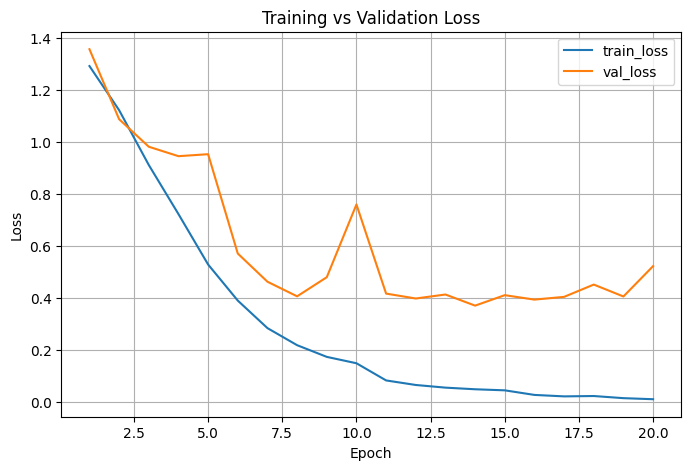

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="train_loss")
plt.plot(history["epoch"], history["val_loss"], label="val_loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

### Блок 25. Описание
В этом блоке выполняется код ниже. (детализацию уточнить при необходимости)

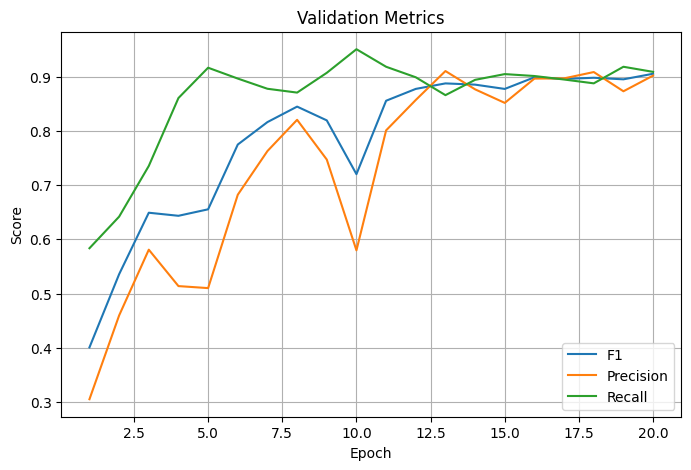

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["val_f1"], label="F1")
plt.plot(history["epoch"], history["val_precision"], label="Precision")
plt.plot(history["epoch"], history["val_recall"], label="Recall")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()
plt.grid()

plt.show()